In [ ]:
print("FLOODWISE AI")
print("Urban Flood Nowcasting System")
print("My first AI project has started!")

FLOODWISE AI
Urban Flood Nowcasting System
My first AI project has started!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("FLOODWISE AI")
print("Libraries loaded successfully!")

FLOODWISE AI
Libraries loaded successfully!


In [ ]:
import pandas as pd

data = {
    "rainfall_mm": [5, 10, 15, 20, 25, 30, 35, 40, 50, 60,
                    8, 12, 18, 22, 28, 33, 45, 55, 65, 70],

    "drainage_capacity": [90, 85, 80, 75, 70, 65, 60, 55, 45, 40,
                          90, 85, 78, 72, 68, 62, 50, 45, 35, 30],

    "elevation_m": [12, 15, 18, 10, 8, 7, 5, 6, 4, 3,
                    14, 16, 11, 9, 7, 6, 5, 4, 3, 2],

    "flood": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
              0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

print("FLOODWISE AI DATASET")
print("--------------------")
print(df)

FLOODWISE AI DATASET
--------------------
    rainfall_mm  drainage_capacity  elevation_m  flood
0             5                 90           12      0
1            10                 85           15      0
2            15                 80           18      0
3            20                 75           10      0
4            25                 70            8      0
5            30                 65            7      1
6            35                 60            5      1
7            40                 55            6      1
8            50                 45            4      1
9            60                 40            3      1
10            8                 90           14      0
11           12                 85           16      0
12           18                 78           11      0
13           22                 72            9      0
14           28                 68            7      1
15           33                 62            6      1
16           45        

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Input features
X = df[["rainfall_mm", "drainage_capacity", "elevation_m"]]

# Target
y = df["flood"]

# Training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create AI model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the AI
model.fit(X_train, y_train)

# Test the AI
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("FLOODWISE AI MODEL TRAINED!")
print("Model Accuracy:", accuracy)

FLOODWISE AI MODEL TRAINED!
Model Accuracy: 1.0


In [ ]:
rainfall = 45
drainage_capacity = 50
elevation = 5

new_data = pd.DataFrame({
    "rainfall_mm": [rainfall],
    "drainage_capacity": [drainage_capacity],
    "elevation_m": [elevation]
})

prediction = model.predict(new_data)

if prediction[0] == 1:
    print(" FLOOD ALERT!")
    print("High risk of urban flooding.")
else:
    print(" LOW FLOOD RISK")
    print("Flood is unlikely.")

 FLOOD ALERT!
High risk of urban flooding.


In [ ]:
def flood_risk(rainfall, drainage, elevation):
    score = 0

    # Rainfall
    if rainfall >= 50:
        score += 3
    elif rainfall >= 25:
        score += 2
    else:
        score += 1

    # Drainage
    if drainage < 50:
        score += 3
    elif drainage < 75:
        score += 2
    else:
        score += 1

    # Elevation
    if elevation < 5:
        score += 3
    elif elevation < 10:
        score += 2
    else:
        score += 1

    if score >= 7:
        return "HIGH RISK "
    elif score >= 5:
        return "MEDIUM RISK "
    else:
        return "LOW RISK "


rainfall = 45
drainage = 50
elevation = 5

risk = flood_risk(rainfall, drainage, elevation)

print(" Rainfall:", rainfall, "mm")
print(" Drainage Capacity:", drainage)
print(" Elevation:", elevation, "m")
print("----------------------------")
print("FLOOD RISK:", risk)

 Rainfall: 45 mm
 Drainage Capacity: 50
 Elevation: 5 m
----------------------------
FLOOD RISK: MEDIUM RISK 


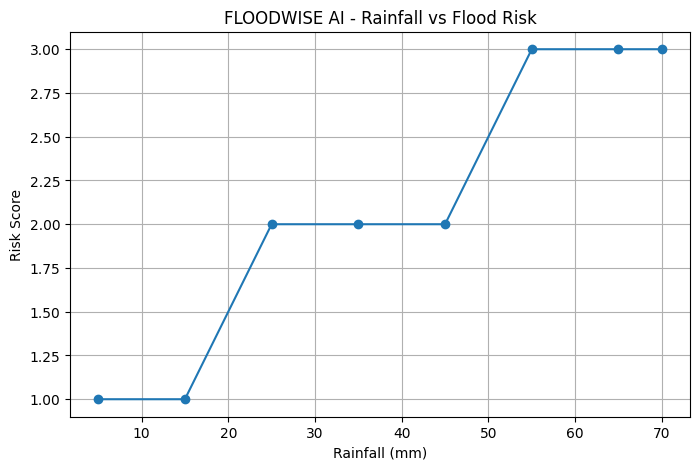

In [ ]:
import matplotlib.pyplot as plt

rainfall_values = [5, 15, 25, 35, 45, 55, 65, 70]

risk_scores = []

for rainfall in rainfall_values:
    score = 0

    if rainfall >= 50:
        score += 3
    elif rainfall >= 25:
        score += 2
    else:
        score += 1

    risk_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(rainfall_values, risk_scores, marker="o")

plt.title("FLOODWISE AI - Rainfall vs Flood Risk")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Risk Score")
plt.grid(True)

plt.show()

In [ ]:
import folium

# Create a map
flood_map = folium.Map(
    location=[22.50, 88.34],
    zoom_start=12
)

# Example locations
locations = [
    [22.50, 88.34, "High Risk"],
    [22.52, 88.36, "Medium Risk"],
    [22.48, 88.32, "Low Risk"],
    [22.54, 88.38, "High Risk"],
    [22.47, 88.35, "Medium Risk"]
]

# Add markers
for lat, lon, risk in locations:

    if risk == "High Risk":
        color = "red"
    elif risk == "Medium Risk":
        color = "orange"
    else:
        color = "green"

    folium.Marker(
        location=[lat, lon],
        popup=f"Flood Risk: {risk}",
        icon=folium.Icon(color=color)
    ).add_to(flood_map)

flood_map

In [ ]:
import folium

# Different urban locations
locations = [
    [22.50, 88.34, 45, 50, 5],
    [22.52, 88.36, 20, 80, 12],
    [22.48, 88.32, 60, 40, 3],
    [22.54, 88.38, 30, 60, 7],
    [22.47, 88.35, 55, 35, 4]
]

# Create map
flood_map = folium.Map(
    location=[22.50, 88.34],
    zoom_start=12
)

for lat, lon, rainfall, drainage, elevation in locations:

    # AI prediction
    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation]
    })

    prediction = model.predict(new_data)[0]

    if prediction == 1:
        risk = "HIGH RISK"
        color = "red"
    else:
        risk = "LOW RISK"
        color = "green"

    popup_text = f"""
    Rainfall: {rainfall} mm<br>
    Drainage Capacity: {drainage}<br>
    Elevation: {elevation} m<br>
    <b>AI Prediction: {risk}</b>
    """

    folium.Marker(
        location=[lat, lon],
        popup=popup_text,
        icon=folium.Icon(color=color)
    ).add_to(flood_map)

flood_map

In [ ]:
def estimate_water_depth(rainfall, drainage, elevation):
    depth = (rainfall * 0.08) - (drainage * 0.02) - (elevation * 0.03)

    if depth < 0:
        depth = 0

    return round(depth, 2)


rainfall = 60
drainage = 40
elevation = 3

water_depth = estimate_water_depth(
    rainfall,
    drainage,
    elevation
)

print(" Rainfall:", rainfall, "mm")
print(" Drainage Capacity:", drainage)
print(" Elevation:", elevation, "m")
print("----------------------------")
print(" Estimated Water Depth:", water_depth, "meters")

 Rainfall: 60 mm
 Drainage Capacity: 40
 Elevation: 3 m
----------------------------
 Estimated Water Depth: 3.91 meters


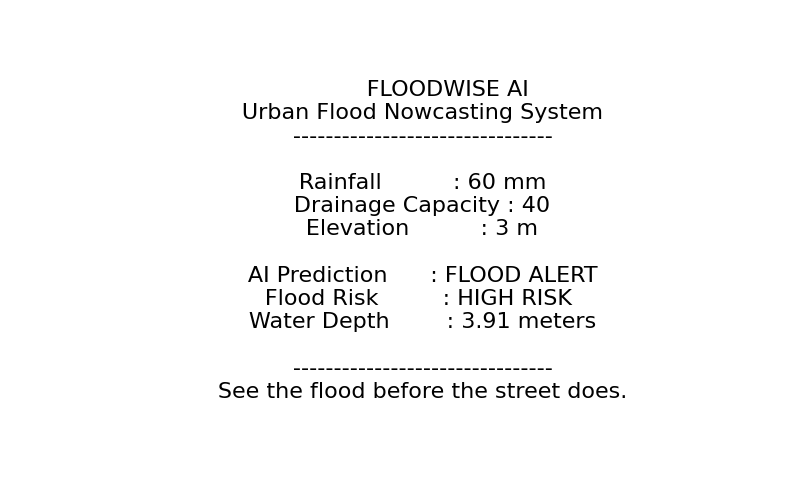

In [ ]:
import matplotlib.pyplot as plt

# Current location data
rainfall = 60
drainage = 40
elevation = 3

# AI flood prediction
new_data = pd.DataFrame({
    "rainfall_mm": [rainfall],
    "drainage_capacity": [drainage],
    "elevation_m": [elevation]
})

prediction = model.predict(new_data)[0]

if prediction == 1:
    flood_status = "FLOOD ALERT"
else:
    flood_status = "LOW FLOOD RISK"

# Risk calculation
risk = flood_risk(rainfall, drainage, elevation)

# Water depth
water_depth = estimate_water_depth(
    rainfall,
    drainage,
    elevation
)

# Dashboard
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

dashboard_text = f"""
              FLOODWISE AI
       Urban Flood Nowcasting System
       --------------------------------

       Rainfall          : {rainfall} mm
       Drainage Capacity : {drainage}
       Elevation          : {elevation} m

       AI Prediction      : {flood_status}
       Flood Risk         : {risk}
       Water Depth        : {water_depth} meters

       --------------------------------
       See the flood before the street does.
"""

ax.text(
    0.5, 0.5,
    dashboard_text,
    ha="center",
    va="center",
    fontsize=16
)

plt.show()

In [ ]:
!pip -q install gradio

In [ ]:
import gradio as gr

def predict_flood(rainfall, drainage, elevation):

    # AI prediction
    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation]
    })

    prediction = model.predict(new_data)[0]

    if prediction == 1:
        flood_status = " FLOOD ALERT"
    else:
        flood_status = " LOW FLOOD RISK"

    # Risk level
    risk = flood_risk(rainfall, drainage, elevation)

    # Water depth
    depth = estimate_water_depth(
        rainfall,
        drainage,
        elevation
    )

    return flood_status, risk, f"{depth} meters"


app = gr.Interface(
    fn=predict_flood,
    inputs=[
        gr.Slider(0, 100, value=50, label=" Rainfall (mm)"),
        gr.Slider(0, 100, value=50, label=" Drainage Capacity"),
        gr.Slider(0, 20, value=5, label=" Elevation (m)")
    ],
    outputs=[
        gr.Textbox(label=" AI Prediction"),
        gr.Textbox(label=" Flood Risk"),
        gr.Textbox(label=" Estimated Water Depth")
    ],
    title=" FLOODWISE AI",
    description="See the flood before the street does."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://970c99b09d0c6ee746.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

rainfall = np.random.randint(5, 101, n)
drainage = np.random.randint(20, 101, n)
elevation = np.random.uniform(1, 20, n)

# Prototype flood rule
flood_score = (
    (rainfall >= 50).astype(int)
    + (drainage <= 50).astype(int)
    + (elevation <= 5).astype(int)
)

flood = (flood_score >= 2).astype(int)

dataset = pd.DataFrame({
    "rainfall_mm": rainfall,
    "drainage_capacity": drainage,
    "elevation_m": elevation.round(2),
    "flood": flood
})

print("Dataset created successfully!")
print("Number of records:", len(dataset))
print()
print(dataset.head(10))

Dataset created successfully!
Number of records: 500

   rainfall_mm  drainage_capacity  elevation_m  flood
0           56                 29        14.56      1
1           97                 88        18.09      0
2           19                 53        12.86      0
3           76                 71        11.26      0
4           65                 29         9.34      1
5           25                 38        11.97      0
6           87                 77         7.75      0
7           91                 20         8.44      1
8           79                 88        11.11      0
9           79                 23         2.27      1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = dataset[[
    "rainfall_mm",
    "drainage_capacity",
    "elevation_m"
]]

# Target
y = dataset["flood"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model
model_v2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
model_v2.fit(X_train, y_train)

# Prediction
y_pred = model_v2.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(" FLOODWISE AI V2")
print("----------------------")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred))

 FLOODWISE AI V2
----------------------
Training records: 400
Testing records: 100
Model Accuracy: 100.0 %

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00        32

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
import pandas as pd
import numpy as np

np.random.seed(10)

n = 1000

rainfall = np.random.uniform(5, 120, n)
drainage = np.random.uniform(20, 100, n)
elevation = np.random.uniform(1, 25, n)
previous_water = np.random.uniform(0, 2.5, n)
blockage = np.random.uniform(0, 100, n)

# Create a more realistic prototype flood score
score = (
    rainfall * 0.035
    + previous_water * 1.2
    + blockage * 0.018
    - drainage * 0.018
    - elevation * 0.025
    + np.random.normal(0, 0.35, n)
)

# Flood occurrence
flood = (score > 2.2).astype(int)

realistic_dataset = pd.DataFrame({
    "rainfall_mm": rainfall.round(2),
    "drainage_capacity": drainage.round(2),
    "elevation_m": elevation.round(2),
    "previous_water_level_m": previous_water.round(2),
    "drainage_blockage_percent": blockage.round(2),
    "flood": flood
})

print(" FLOODWISE AI - REALISTIC PROTOTYPE DATASET")
print("-----------------------------------------------")
print("Total records:", len(realistic_dataset))
print()
print(realistic_dataset.head(10))
print()
print("Flood cases:", realistic_dataset["flood"].sum())
print("No-flood cases:", (realistic_dataset["flood"] == 0).sum())

 FLOODWISE AI - REALISTIC PROTOTYPE DATASET
-----------------------------------------------
Total records: 1000

   rainfall_mm  drainage_capacity  elevation_m  previous_water_level_m  \
0        93.70              47.87        15.15                    2.36   
1         7.39              84.72        19.56                    0.17   
2        77.87              56.77        14.40                    1.57   
3        91.11              70.09         5.45                    1.04   
4        62.33              36.29         9.82                    1.61   
5        30.85              27.49        17.56                    1.39   
6        27.78              98.04        19.56                    1.76   
7        92.46              49.39         9.38                    0.96   
8        24.45              66.10         5.10                    1.04   
9        15.16              39.67         4.30                    0.40   

   drainage_blockage_percent  flood  
0                      62.56      

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = realistic_dataset[
    [
        "rainfall_mm",
        "drainage_capacity",
        "elevation_m",
        "previous_water_level_m",
        "drainage_blockage_percent"
    ]
]

# Target
y = realistic_dataset["flood"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
model_v3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
model_v3.fit(X_train, y_train)

# Predict
y_pred = model_v3.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(" FLOODWISE AI — MODEL V3")
print("----------------------------")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

 FLOODWISE AI — MODEL V3
----------------------------
Training records: 800
Testing records: 200
Accuracy: 92.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        61
           1       0.93      0.96      0.94       139

    accuracy                           0.92       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.92      0.92      0.92       200



In [ ]:
def flood_probability(rainfall, drainage, elevation, previous_water, blockage):

    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation],
        "previous_water_level_m": [previous_water],
        "drainage_blockage_percent": [blockage]
    })

    probability = model_v3.predict_proba(new_data)[0][1]

    prediction = model_v3.predict(new_data)[0]

    return prediction, round(probability * 100, 2)


# Test location
prediction, probability = flood_probability(
    rainfall=80,
    drainage=35,
    elevation=3,
    previous_water=1.5,
    blockage=65
)

print(" FLOODWISE AI")
print("----------------------")
print("Flood Probability:", probability, "%")

if prediction == 1:
    print(" FLOOD ALERT")
else:
    print(" LOW FLOOD RISK")

 FLOODWISE AI
----------------------
Flood Probability: 100.0 %
 FLOOD ALERT


In [ ]:
def floodwise_prediction(
    rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation],
        "previous_water_level_m": [previous_water],
        "drainage_blockage_percent": [blockage]
    })

    # AI probability
    probability = model_v3.predict_proba(new_data)[0][1] * 100

    # AI prediction
    prediction = model_v3.predict(new_data)[0]

    # Risk level
    if probability >= 75:
        risk = "HIGH RISK "
    elif probability >= 40:
        risk = "MEDIUM RISK "
    else:
        risk = "LOW RISK "

    # Prototype water-depth estimate
    depth = estimate_water_depth(
        rainfall,
        drainage,
        elevation
    )

    return probability, prediction, risk, depth


# Test
probability, prediction, risk, depth = floodwise_prediction(
    80,    # rainfall
    35,    # drainage
    3,     # elevation
    1.5,   # previous water level
    65     # drainage blockage
)

print(" FLOODWISE AI")
print("==============================")
print(f"Flood Probability : {probability:.2f}%")
print(f"AI Prediction     : {'FLOOD ALERT ' if prediction == 1 else 'NO FLOOD '}")
print(f"Risk Level        : {risk}")
print(f"Water Depth       : {depth} meters")

 FLOODWISE AI
Flood Probability : 100.00%
AI Prediction     : FLOOD ALERT 
Risk Level        : HIGH RISK 
Water Depth       : 5.61 meters


In [ ]:
import gradio as gr

def dashboard_prediction(
    rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    status = "FLOOD ALERT" if prediction == 1 else  "NO FLOOD"

    return (
        f"{probability:.2f}%",
        status,
        risk,
        f"{depth:.2f} meters"
    )


app_v2 = gr.Interface(
    fn=dashboard_prediction,

    inputs=[
        gr.Slider(5, 120, value=50, label=" Rainfall (mm)"),
        gr.Slider(20, 100, value=60, label=" Drainage Capacity"),
        gr.Slider(1, 25, value=10, label=" Elevation (m)"),
        gr.Slider(0, 2.5, value=0.5, label=" Previous Water Level (m)"),
        gr.Slider(0, 100, value=20, label=" Drainage Blockage (%)")
    ],

    outputs=[
        gr.Textbox(label=" Flood Probability"),
        gr.Textbox(label=" AI Prediction"),
        gr.Textbox(label=" Risk Level"),
        gr.Textbox(label=" Estimated Water Depth")
    ],

    title=" FLOODWISE AI",
    description="See the flood before the street does."
)

app_v2.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a951b1ecb6627c7556.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import folium

# Example urban locations
locations = [
    [22.50, 88.34, 80, 35, 3, 1.5, 65],
    [22.52, 88.36, 30, 85, 15, 0.2, 10],
    [22.48, 88.32, 65, 45, 4, 1.0, 55],
    [22.54, 88.38, 45, 60, 8, 0.5, 30],
    [22.47, 88.35, 90, 30, 2, 2.0, 80]
]

flood_map = folium.Map(
    location=[22.50, 88.35],
    zoom_start=12
)

for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    if probability >= 75:
        color = "red"
    elif probability >= 40:
        color = "orange"
    else:
        color = "green"

    popup = f"""
    <b>FLOODWISE AI</b><br>
    Rainfall: {rainfall:.1f} mm<br>
    Drainage Capacity: {drainage:.1f}<br>
    Elevation: {elevation:.1f} m<br>
    Previous Water: {previous_water:.1f} m<br>
    Drainage Blockage: {blockage:.1f}%<br>
    <b>Flood Probability: {probability:.1f}%</b><br>
    <b>Risk: {risk}</b><br>
    Water Depth: {depth:.2f} m
    """

    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup, max_width=300),
        icon=folium.Icon(color=color)
    ).add_to(flood_map)

flood_map

In [ ]:
# STEP 23 - Simple Safe Route Recommendation

safe_locations = []

for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    if probability < 40:
        safe_locations.append({
            "latitude": lat,
            "longitude": lon,
            "flood_probability": round(probability, 2),
            "risk": "LOW RISK",
            "water_depth": round(depth, 2)
        })

print(" FLOODWISE AI - SAFE ROUTE OPTIONS")
print("======================================")

if len(safe_locations) == 0:
    print(" No low-risk route found.")
else:
    for i, location in enumerate(safe_locations, 1):
        print(f"\nSafe Option {i}")
        print("Location:", location["latitude"], location["longitude"])
        print("Flood Probability:", location["flood_probability"], "%")
        print("Risk:", location["risk"])
        print("Water Depth:", location["water_depth"], "m")

 FLOODWISE AI - SAFE ROUTE OPTIONS

Safe Option 1
Location: 22.52 88.36
Flood Probability: 2.5 %
Risk: LOW RISK
Water Depth: 0.25 m

Safe Option 2
Location: 22.54 88.38
Flood Probability: 8.0 %
Risk: LOW RISK
Water Depth: 2.16 m


In [ ]:
# STEP 24 - Improved Safe Route Logic

safe_locations = []

for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    # A route is considered safer only when
    # both flood probability and water depth are low
    if probability < 40 and depth < 0.5:

        safe_locations.append({
            "latitude": lat,
            "longitude": lon,
            "flood_probability": round(probability, 2),
            "water_depth": round(depth, 2)
        })

print(" FLOODWISE AI - IMPROVED SAFE ROUTES")
print("========================================")

if len(safe_locations) == 0:
    print(" No sufficiently safe route found.")
else:
    for i, location in enumerate(safe_locations, 1):
        print(f"\n Safe Option {i}")
        print("Location:", location["latitude"], location["longitude"])
        print("Flood Probability:", location["flood_probability"], "%")
        print("Estimated Water Depth:", location["water_depth"], "m")

 FLOODWISE AI - IMPROVED SAFE ROUTES

 Safe Option 1
Location: 22.52 88.36
Flood Probability: 2.5 %
Estimated Water Depth: 0.25 m


In [ ]:
import folium

safe_map = folium.Map(
    location=[22.51, 88.35],
    zoom_start=13
)

for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    # Risk color
    if probability >= 75:
        color = "red"
    elif probability >= 40:
        color = "orange"
    else:
        color = "green"

    # Safe condition
    if probability < 40 and depth < 0.5:
        popup_text = f"""
        <b> SAFE LOCATION</b><br>
        Flood Probability: {probability:.2f}%<br>
        Water Depth: {depth:.2f} m<br>
        Rainfall: {rainfall} mm<br>
        Drainage Capacity: {drainage}
        """
    else:
        popup_text = f"""
        <b>{risk}</b><br>
        Flood Probability: {probability:.2f}%<br>
        Water Depth: {depth:.2f} m<br>
        Rainfall: {rainfall} mm
        """

    folium.Marker(
        [lat, lon],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=color)
    ).add_to(safe_map)

safe_map

In [ ]:
import joblib

joblib.dump(model_v3, "floodwise_model.pkl")

print(" FLOODWISE AI model saved successfully!")

 FLOODWISE AI model saved successfully!


In [ ]:
from google.colab import files

files.download("floodwise_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
realistic_dataset.to_csv("floodwise_dataset.csv", index=False)

print(" FLOODWISE AI dataset saved successfully!")

 FLOODWISE AI dataset saved successfully!


In [ ]:
from google.colab import files

files.download("floodwise_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 FLOODWISE AI - FEATURE IMPORTANCE
                     Feature  Importance
0                rainfall_mm    0.455421
3     previous_water_level_m    0.250806
4  drainage_blockage_percent    0.126294
1          drainage_capacity    0.105056
2                elevation_m    0.062423


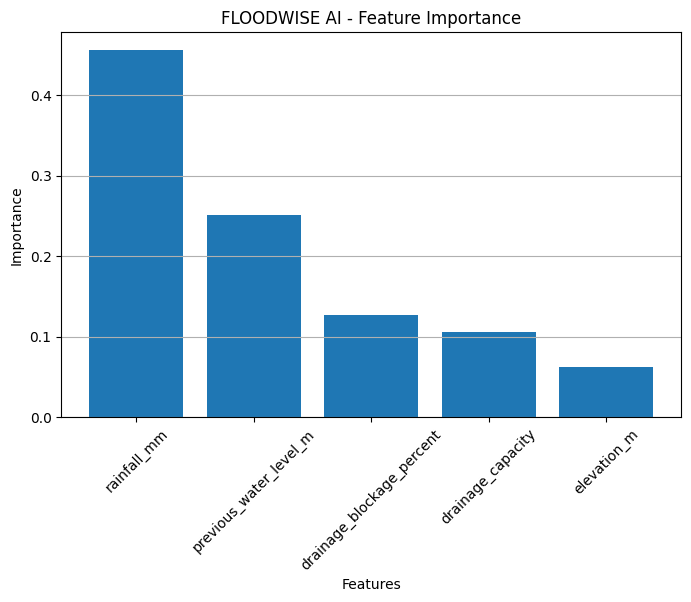

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_v3.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(" FLOODWISE AI - FEATURE IMPORTANCE")
print("====================================")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("FLOODWISE AI - Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

 FLOODWISE AI - DRAINAGE BLOCKAGE SIMULATOR
Blockage: 0%  →  Flood Probability: 65.00%
Blockage: 20%  →  Flood Probability: 96.00%
Blockage: 40%  →  Flood Probability: 97.50%
Blockage: 60%  →  Flood Probability: 98.00%
Blockage: 80%  →  Flood Probability: 97.50%
Blockage: 100%  →  Flood Probability: 98.00%


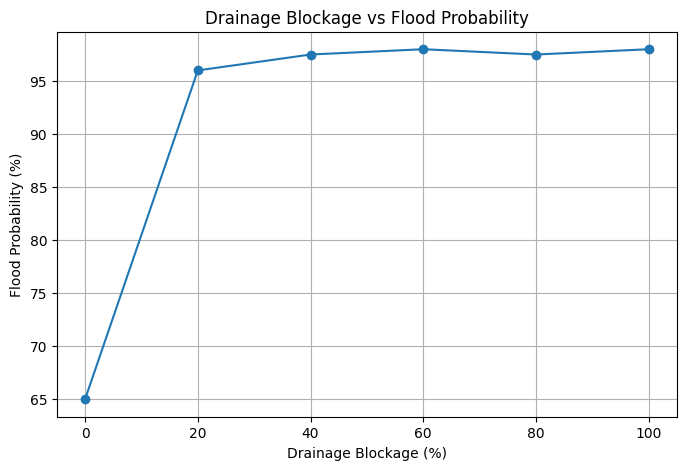

In [ ]:
blockage_values = [0, 20, 40, 60, 80, 100]
probabilities = []

for blockage in blockage_values:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall=80,
        drainage=50,
        elevation=5,
        previous_water=1.0,
        blockage=blockage
    )

    probabilities.append(probability)

print(" FLOODWISE AI - DRAINAGE BLOCKAGE SIMULATOR")
print("==============================================")

for b, p in zip(blockage_values, probabilities):
    print(f"Blockage: {b}%  →  Flood Probability: {p:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(blockage_values, probabilities, marker="o")

plt.title("Drainage Blockage vs Flood Probability")
plt.xlabel("Drainage Blockage (%)")
plt.ylabel("Flood Probability (%)")
plt.grid(True)

plt.show()

In [ ]:
def nowcast_0_3_hours(
    current_rainfall,
    next_1h_rainfall,
    next_2h_rainfall,
    next_3h_rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    rainfall_forecast = [
        current_rainfall,
        next_1h_rainfall,
        next_2h_rainfall,
        next_3h_rainfall
    ]

    results = []

    for hour, rainfall in enumerate(rainfall_forecast):

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        results.append({
            "Time": f"{hour} Hour",
            "Rainfall (mm)": rainfall,
            "Flood Probability (%)": round(probability, 2),
            "Risk": risk,
            "Water Depth (m)": round(depth, 2)
        })

    return pd.DataFrame(results)


nowcast_result = nowcast_0_3_hours(
    current_rainfall=40,
    next_1h_rainfall=55,
    next_2h_rainfall=70,
    next_3h_rainfall=85,
    drainage=45,
    elevation=5,
    previous_water=1.0,
    blockage=50
)

print(" FLOODWISE AI - 0–3 HOUR NOWCAST")
print("===================================")

display(nowcast_result)

 FLOODWISE AI - 0–3 HOUR NOWCAST


,Time,Rainfall (mm),Flood Probability (%),Risk,Water Depth (m)
0,0 Hour,40,62.0,MEDIUM RISK,2.15
1,1 Hour,55,94.5,HIGH RISK,3.35
2,2 Hour,70,96.0,HIGH RISK,4.55
3,3 Hour,85,97.0,HIGH RISK,5.75


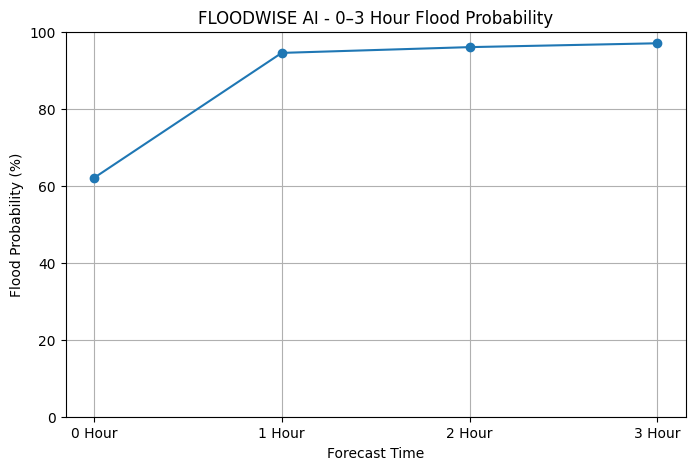

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    nowcast_result["Time"],
    nowcast_result["Flood Probability (%)"],
    marker="o"
)

plt.title("FLOODWISE AI - 0–3 Hour Flood Probability")
plt.xlabel("Forecast Time")
plt.ylabel("Flood Probability (%)")
plt.ylim(0, 100)
plt.grid(True)

plt.show()

In [ ]:
# 🌧️ FLOODWISE AI - Real Data Pipeline Test

test_rainfall = 65

probability, prediction, risk, depth = floodwise_prediction(
    rainfall=test_rainfall,
    drainage=50,
    elevation=5,
    previous_water=1.0,
    blockage=40
)

print(" FLOODWISE AI REAL DATA PIPELINE TEST")
print("=======================================")
print("Rainfall:", test_rainfall, "mm")
print("Flood Probability:", round(probability, 2), "%")
print("Prediction:", " FLOOD" if prediction == 1 else " NO FLOOD")
print("Risk:", risk)
print("Estimated Water Depth:", round(depth, 2), "m")

 FLOODWISE AI REAL DATA PIPELINE TEST
Rainfall: 65 mm
Flood Probability: 95.5 %
Prediction:  FLOOD
Risk: HIGH RISK 
Estimated Water Depth: 4.05 m


In [ ]:
import requests

url = "https://mausam.imd.gov.in/api/current_wx_api.php?id=42182"

response = requests.get(url)

print("Status Code:", response.status_code)
print(response.text[:2000])

Status Code: 401
Your IP/Domain 34.48.126.233 needs to be whitelisted


In [ ]:
import requests
import pandas as pd

latitude = 22.52
longitude = 88.36

url = (
    "https://api.open-meteo.com/v1/forecast"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    "&hourly=rain,precipitation"
    "&forecast_days=2"
    "&timezone=Asia/Kolkata"
)

response = requests.get(url)

print("Status Code:", response.status_code)

weather_data = response.json()

rainfall_data = pd.DataFrame({
    "time": weather_data["hourly"]["time"],
    "rain_mm": weather_data["hourly"]["rain"],
    "precipitation_mm": weather_data["hourly"]["precipitation"]
})

print(rainfall_data.head(10))

Status Code: 200
               time  rain_mm  precipitation_mm
0  2026-09-09T00:00      0.0               0.0
1  2026-09-09T01:00      0.6               0.6
2  2026-09-09T02:00      0.3               0.3
3  2026-09-09T03:00      0.0               0.0
4  2026-09-09T04:00      0.0               0.0
5  2026-09-09T05:00      0.0               0.0
6  2026-09-09T06:00      0.0               0.0
7  2026-09-09T07:00      0.0               0.0
8  2026-09-09T08:00      0.0               0.0
9  2026-09-09T09:00      0.0               0.0


In [ ]:
# Take the next 4 hours of rainfall
next_4_hours = rainfall_data.head(4)

print(" REAL WEATHER → FLOODWISE AI")
print("================================")

for i, row in next_4_hours.iterrows():

    rainfall = float(row["rain_mm"])

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall=rainfall,
        drainage=50,
        elevation=5,
        previous_water=1.0,
        blockage=40
    )

    print(f"\n {row['time']}")
    print(f"Rainfall: {rainfall:.2f} mm")
    print(f"Flood Probability: {probability:.2f}%")
    print(f"Prediction: {' FLOOD' if prediction == 1 else ' NO FLOOD'}")
    print(f"Risk: {risk}")
    print(f"Estimated Water Depth: {depth:.2f} m")

 REAL WEATHER → FLOODWISE AI

 2026-09-09T00:00
Rainfall: 0.00 mm
Flood Probability: 16.50%
Prediction:  NO FLOOD
Risk: LOW RISK 
Estimated Water Depth: 0.00 m

 2026-09-09T01:00
Rainfall: 0.60 mm
Flood Probability: 16.50%
Prediction:  NO FLOOD
Risk: LOW RISK 
Estimated Water Depth: 0.00 m

 2026-09-09T02:00
Rainfall: 0.30 mm
Flood Probability: 16.50%
Prediction:  NO FLOOD
Risk: LOW RISK 
Estimated Water Depth: 0.00 m

 2026-09-09T03:00
Rainfall: 0.00 mm
Flood Probability: 16.50%
Prediction:  NO FLOOD
Risk: LOW RISK 
Estimated Water Depth: 0.00 m


In [ ]:
real_nowcast = []

for i, row in rainfall_data.head(4).iterrows():

    rainfall = float(row["rain_mm"])

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall=rainfall,
        drainage=50,
        elevation=5,
        previous_water=1.0,
        blockage=40
    )

    real_nowcast.append({
        "Time": row["time"],
        "Rainfall (mm)": round(rainfall, 2),
        "Flood Probability (%)": round(probability, 2),
        "Prediction": "FLOOD" if prediction == 1 else "NO FLOOD",
        "Risk": risk,
        "Water Depth (m)": round(depth, 2)
    })

real_nowcast_df = pd.DataFrame(real_nowcast)

print(" FLOODWISE AI - REAL 0–3 HOUR NOWCAST")
print("========================================")

display(real_nowcast_df)

 FLOODWISE AI - REAL 0–3 HOUR NOWCAST


,Time,Rainfall (mm),Flood Probability (%),Prediction,Risk,Water Depth (m)
0,2026-09-09T00:00,0.0,16.5,NO FLOOD,LOW RISK,0
1,2026-09-09T01:00,0.6,16.5,NO FLOOD,LOW RISK,0
2,2026-09-09T02:00,0.3,16.5,NO FLOOD,LOW RISK,0
3,2026-09-09T03:00,0.0,16.5,NO FLOOD,LOW RISK,0


In [ ]:
import folium

real_rainfall = float(rainfall_data.iloc[0]["rain_mm"])

probability, prediction, risk, depth = floodwise_prediction(
    rainfall=real_rainfall,
    drainage=50,
    elevation=5,
    previous_water=1.0,
    blockage=40
)

# Create map
real_weather_map = folium.Map(
    location=[22.52, 88.36],
    zoom_start=13
)

# Select marker color
if probability >= 75:
    color = "red"
elif probability >= 40:
    color = "orange"
else:
    color = "green"

popup_text = f"""
<b> FLOODWISE AI</b><br><br>
Rainfall: {real_rainfall:.2f} mm<br>
Flood Probability: {probability:.2f}%<br>
Risk: {risk}<br>
Estimated Water Depth: {depth:.2f} m
"""

folium.Marker(
    [22.52, 88.36],
    popup=folium.Popup(popup_text, max_width=300),
    tooltip="FLOODWISE AI - Real Weather",
    icon=folium.Icon(color=color)
).add_to(real_weather_map)

real_weather_map

In [ ]:
!pip -q install fastapi uvicorn nest-asyncio

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="FLOODWISE AI API")


class FloodInput(BaseModel):
    rainfall: float
    drainage: float
    elevation: float
    previous_water: float
    blockage: float


@app.get("/")
def home():
    return {
        "message": " FLOODWISE AI Backend is running!"
    }


@app.post("/predict")
def predict_flood(data: FloodInput):

    probability, prediction, risk, depth = floodwise_prediction(
        data.rainfall,
        data.drainage,
        data.elevation,
        data.previous_water,
        data.blockage
    )

    return {
        "flood_probability": probability,
        "prediction": "FLOOD" if prediction == 1 else "NO FLOOD",
        "risk": risk,
        "estimated_water_depth_m": depth
    }


print(" FLOODWISE AI Backend API created!")

 FLOODWISE AI Backend API created!


In [ ]:
print("FLOODWISE AI Backend is ready!")
print("API endpoint: /predict")

FLOODWISE AI Backend is ready!
API endpoint: /predict


In [ ]:
test_input = FloodInput(
    rainfall=65,
    drainage=50,
    elevation=5,
    previous_water=1.0,
    blockage=40
)

result = predict_flood(test_input)

print(" FLOODWISE AI API TEST")
print("========================")
print(result)

 FLOODWISE AI API TEST
{'flood_probability': np.float64(95.5), 'prediction': 'FLOOD', 'risk': 'HIGH RISK ', 'estimated_water_depth_m': 4.05}


In [ ]:
backend_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(title="FLOODWISE AI API")

model = joblib.load("floodwise_model.pkl")


class FloodInput(BaseModel):
    rainfall: float
    drainage: float
    elevation: float
    previous_water: float
    blockage: float


@app.get("/")
def home():
    return {
        "message": "FLOODWISE AI Backend is running!"
    }


@app.post("/predict")
def predict_flood(data: FloodInput):

    new_data = pd.DataFrame({
        "rainfall_mm": [data.rainfall],
        "drainage_capacity": [data.drainage],
        "elevation_m": [data.elevation],
        "previous_water_level_m": [data.previous_water],
        "drainage_blockage_percent": [data.blockage]
    })

    probability = model.predict_proba(new_data)[0][1] * 100
    prediction = model.predict(new_data)[0]

    if probability >= 75:
        risk = "HIGH RISK"
    elif probability >= 40:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    return {
        "flood_probability": round(probability, 2),
        "prediction": "FLOOD" if prediction == 1 else "NO FLOOD",
        "risk": risk
    }
'''

with open("backend_api.py", "w") as f:
    f.write(backend_code)

print(" backend_api.py created successfully!")

 backend_api.py created successfully!


In [ ]:
from google.colab import files

files.download("backend_api.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

test_model = joblib.load("floodwise_model.pkl")

print(" Saved FLOODWISE AI model loaded successfully!")
print("Model type:", type(test_model).__name__)

 Saved FLOODWISE AI model loaded successfully!
Model type: RandomForestClassifier


In [ ]:
import gradio as gr

def floodwise_dashboard(
    rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    status = " FLOOD ALERT" if prediction == 1 else " NO FLOOD"

    return (
        f"{probability:.2f}%",
        status,
        risk,
        f"{depth:.2f} m"
    )


dashboard = gr.Interface(
    fn=floodwise_dashboard,

    inputs=[
        gr.Slider(
            minimum=5,
            maximum=120,
            value=50,
            label=" Rainfall (mm)"
        ),

        gr.Slider(
            minimum=20,
            maximum=100,
            value=60,
            label=" Drainage Capacity"
        ),

        gr.Slider(
            minimum=1,
            maximum=25,
            value=10,
            label=" Elevation (m)"
        ),

        gr.Slider(
            minimum=0,
            maximum=2.5,
            value=0.5,
            label="💧 Previous Water Level (m)"
        ),

        gr.Slider(
            minimum=0,
            maximum=100,
            value=20,
            label=" Drainage Blockage (%)"
        )
    ],

    outputs=[
        gr.Textbox(label=" Flood Probability"),
        gr.Textbox(label=" AI Prediction"),
        gr.Textbox(label=" Risk Level"),
        gr.Textbox(label=" Estimated Water Depth")
    ],

    title=" FLOODWISE AI",
    description="See the flood before the street does."
)

dashboard.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b271cea122d3dc26f4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import requests
import pandas as pd

def get_real_rainfall():
    latitude = 22.52
    longitude = 88.36

    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={latitude}"
        f"&longitude={longitude}"
        "&hourly=rain"
        "&forecast_days=1"
        "&timezone=Asia/Kolkata"
    )

    response = requests.get(url)
    data = response.json()

    rainfall = data["hourly"]["rain"][:4]

    return rainfall


real_rainfall = get_real_rainfall()

print("🌧️ REAL WEATHER DATA")
print("====================")

for hour, rain in enumerate(real_rainfall):
    print(f"Hour {hour}: {rain} mm")

🌧️ REAL WEATHER DATA
Hour 0: 0.0 mm
Hour 1: 0.6 mm
Hour 2: 0.3 mm
Hour 3: 0.0 mm


In [ ]:
def real_weather_prediction():
    rainfall = get_real_rainfall()[0]

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall=rainfall,
        drainage=50,
        elevation=5,
        previous_water=1.0,
        blockage=40
    )

    return (
        f"{rainfall:.2f} mm",
        f"{probability:.2f}%",
        " FLOOD" if prediction == 1 else " NO FLOOD",
        risk,
        f"{depth:.2f} m"
    )


real_weather_dashboard = gr.Interface(
    fn=real_weather_prediction,

    inputs=[],

    outputs=[
        gr.Textbox(label=" Current Rainfall"),
        gr.Textbox(label=" Flood Probability"),
        gr.Textbox(label=" AI Prediction"),
        gr.Textbox(label=" Risk Level"),
        gr.Textbox(label=" Estimated Water Depth")
    ],

    title=" FLOODWISE AI — Real Weather",
    description="Real weather rainfall → AI flood prediction"
)

real_weather_dashboard.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db7ae5088f1b291e85.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import folium
from IPython.display import display

# Create Flood Risk Map
frontend_map = folium.Map(
    location=[22.51, 88.35],
    zoom_start=13
)

# Add all locations
for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    # Risk-based marker color
    if probability >= 75:
        color = "red"
    elif probability >= 40:
        color = "orange"
    else:
        color = "green"

    popup_text = f"""
    <b> FLOODWISE AI</b><br><br>
    Rainfall: {rainfall} mm<br>
    Flood Probability: {probability:.2f}%<br>
    Risk: {risk}<br>
    Estimated Water Depth: {depth:.2f} m<br>
    Drainage Capacity: {drainage}<br>
    Blockage: {blockage}%
    """

    folium.Marker(
        [lat, lon],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip="FLOODWISE AI",
        icon=folium.Icon(color=color)
    ).add_to(frontend_map)

print(" FLOODWISE AI GIS MAP")
print("=======================")

display(frontend_map)

 FLOODWISE AI GIS MAP


In [ ]:
import gradio as gr

print(" Professional FLOODWISE AI Dashboard started!")

 Professional FLOODWISE AI Dashboard started!


In [ ]:
import gradio as gr

with gr.Blocks(title="FLOODWISE AI") as professional_dashboard:

    gr.Markdown("""
    #  FLOODWISE AI
    ### *See the flood before the street does.*

    **Urban Flood Nowcasting & Risk Intelligence System**
    """)

    gr.Markdown("##  Flood Prediction Inputs")

    with gr.Row():
        rainfall = gr.Slider(0, 120, value=50, label=" Rainfall (mm)")
        drainage = gr.Slider(0, 100, value=60, label=" Drainage Capacity")

    with gr.Row():
        elevation = gr.Slider(0, 25, value=10, label=" Elevation (m)")
        previous_water = gr.Slider(0, 2.5, value=0.5, label=" Previous Water Level (m)")
        blockage = gr.Slider(0, 100, value=20, label=" Drainage Blockage (%)")

    predict_button = gr.Button(
        " ANALYZE FLOOD RISK",
        variant="primary"
    )

    gr.Markdown("##  AI Prediction")

    with gr.Row():
        probability = gr.Textbox(label="Flood Probability")
        prediction = gr.Textbox(label="AI Prediction")
        risk = gr.Textbox(label="Risk Level")
        depth = gr.Textbox(label="Estimated Water Depth")

    def run_dashboard(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    ):
        probability_value, prediction_value, risk_value, depth_value = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        return (
            f"{probability_value:.2f}%",
            " FLOOD" if prediction_value == 1 else " NO FLOOD",
            risk_value,
            f"{depth_value:.2f} m"
        )

    predict_button.click(
        fn=run_dashboard,
        inputs=[
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        ],
        outputs=[
            probability,
            prediction,
            risk,
            depth
        ]
    )

print(" Professional Dashboard UI created!")

 Professional Dashboard UI created!


In [ ]:
id="mapui1"
import gradio as gr
import folium

def create_flood_map():
    flood_map = folium.Map(
        location=[22.51, 88.35],
        zoom_start=13
    )

    for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        if probability >= 75:
            color = "red"
        elif probability >= 40:
            color = "orange"
        else:
            color = "green"

        popup = f"""
        <b> FLOODWISE AI</b><br><br>
        Rainfall: {rainfall} mm<br>
        Flood Probability: {probability:.2f}%<br>
        Risk: {risk}<br>
        Water Depth: {depth:.2f} m<br>
        Drainage Capacity: {drainage}<br>
        Blockage: {blockage}%
        """

        folium.Marker(
            [lat, lon],
            popup=folium.Popup(popup, max_width=300),
            tooltip="FLOODWISE AI",
            icon=folium.Icon(color=color)
        ).add_to(flood_map)

    return flood_map._repr_html_()


with gr.Blocks(title="FLOODWISE AI") as map_dashboard:

    gr.Markdown("""
    #  FLOODWISE AI
    ### See the flood before the street does.
    """)

    gr.Markdown("##  Flood Risk GIS Map")

    map_html = gr.HTML()

    refresh_map = gr.Button(" Load Flood Risk Map")

    refresh_map.click(
        fn=create_flood_map,
        inputs=[],
        outputs=map_html
    )

    map_dashboard.load(
        fn=create_flood_map,
        inputs=[],
        outputs=map_html
    )

print(" GIS Map integrated into Dashboard!")

 GIS Map integrated into Dashboard!


In [ ]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

def run_nowcast_dashboard(
    current_rainfall,
    next_1h_rainfall,
    next_2h_rainfall,
    next_3h_rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    result = nowcast_0_3_hours(
        current_rainfall,
        next_1h_rainfall,
        next_2h_rainfall,
        next_3h_rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    fig = plt.figure(figsize=(8, 4))

    plt.plot(
        result["Time"],
        result["Flood Probability (%)"],
        marker="o"
    )

    plt.title("FLOODWISE AI - 0–3 Hour Flood Probability")
    plt.xlabel("Forecast Time")
    plt.ylabel("Flood Probability (%)")
    plt.ylim(0, 100)
    plt.grid(True)

    return result, fig


with gr.Blocks(title="FLOODWISE AI — 0–3 Hour Nowcast") as nowcast_dashboard:

    gr.Markdown("""
    # FLOODWISE AI
    ##  0–3 Hour Urban Flood Nowcasting
    """)

    with gr.Row():
        current = gr.Slider(0, 120, value=40, label=" Current Rainfall (mm)")
        hour1 = gr.Slider(0, 120, value=55, label=" Next 1 Hour (mm)")

    with gr.Row():
        hour2 = gr.Slider(0, 120, value=70, label=" Next 2 Hours (mm)")
        hour3 = gr.Slider(0, 120, value=85, label=" Next 3 Hours (mm)")

    with gr.Row():
        drainage_input = gr.Slider(0, 100, value=50, label=" Drainage Capacity")
        elevation_input = gr.Slider(0, 25, value=5, label=" Elevation (m)")

    with gr.Row():
        water_input = gr.Slider(0, 2.5, value=1.0, label=" Previous Water Level (m)")
        blockage_input = gr.Slider(0, 100, value=40, label=" Drainage Blockage (%)")

    analyze = gr.Button(
        " GENERATE 0–3 HOUR NOWCAST",
        variant="primary"
    )

    gr.Markdown("##  Forecast Results")

    result_table = gr.Dataframe(
        label=" Flood Nowcast"
    )

    graph = gr.Plot(
        label=" Flood Probability Trend"
    )

    analyze.click(
        fn=run_nowcast_dashboard,
        inputs=[
            current,
            hour1,
            hour2,
            hour3,
            drainage_input,
            elevation_input,
            water_input,
            blockage_input
        ],
        outputs=[
            result_table,
            graph
        ]
    )

print(" 0–3 Hour Nowcasting Dashboard created!")

 0–3 Hour Nowcasting Dashboard created!


In [ ]:

def recommend_safe_routes(locations):

    route_options = []

    for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        # Safe route condition
        if probability < 40 and depth < 0.5:

            route_options.append({
                "Latitude": lat,
                "Longitude": lon,
                "Flood Probability (%)": round(probability, 2),
                "Water Depth (m)": round(depth, 2),
                "Rainfall (mm)": rainfall,
                "Risk": "LOW RISK"
            })

    # Lowest flood probability first
    route_options = sorted(
        route_options,
        key=lambda x: x["Flood Probability (%)"]
    )

    return pd.DataFrame(route_options)


safe_routes_df = recommend_safe_routes(locations)

print(" FLOODWISE AI — SAFE ROUTE RECOMMENDATION")
print("============================================")

if safe_routes_df.empty:
    print(" No sufficiently safe route/location found.")
else:
    display(safe_routes_df)

 FLOODWISE AI — SAFE ROUTE RECOMMENDATION


,Latitude,Longitude,Flood Probability (%),Water Depth (m),Rainfall (mm),Risk
0,22.52,88.36,2.5,0.25,30,LOW RISK


In [ ]:

def safe_route_dashboard():
    safe_routes = recommend_safe_routes(locations)

    if safe_routes.empty:
        return " No sufficiently safe route/location found."

    text = " FLOODWISE AI — RECOMMENDED SAFE OPTIONS\n"
    text += "=" * 45 + "\n\n"

    for i, row in safe_routes.iterrows():
        text += f" Option {i + 1}\n"
        text += f" Location: {row['Latitude']}, {row['Longitude']}\n"
        text += f" Flood Probability: {row['Flood Probability (%)']}%\n"
        text += f" Water Depth: {row['Water Depth (m)']} m\n"
        text += f" Rainfall: {row['Rainfall (mm)']} mm\n"
        text += f" Risk: {row['Risk']}\n\n"

    return text


with gr.Blocks(title="FLOODWISE AI — Safe Route") as safe_route_dashboard:

    gr.Markdown("""
    #  FLOODWISE AI
    ## Safe Route Recommendation
    """)

    gr.Markdown(
        "The system recommends locations with low predicted flood probability "
        "and low estimated water depth."
    )

    find_route = gr.Button(
        " FIND SAFEST OPTIONS",
        variant="primary"
    )

    route_result = gr.Textbox(
        label=" Recommended Safe Options",
        lines=12
    )

    find_route.click(
        fn=safe_route_dashboard,
        inputs=[],
        outputs=route_result
    )

print(" Safe Route Dashboard created!")

 Safe Route Dashboard created!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import requests
import folium
import gradio as gr

print(" FLOODWISE AI libraries loaded!")

 FLOODWISE AI libraries loaded!


In [ ]:

model_v3 = joblib.load("/content/floodwise_model.pkl")

print(" FLOODWISE AI model loaded successfully!")
print("Model:", type(model_v3).__name__)

 FLOODWISE AI model loaded successfully!
Model: RandomForestClassifier


In [ ]:

realistic_dataset = pd.read_csv(
    "/content/floodwise_dataset.csv"
)

print("FLOODWISE AI dataset loaded!")
print("Rows:", len(realistic_dataset))
print("Columns:", list(realistic_dataset.columns))

 FLOODWISE AI dataset loaded!
Rows: 1000
Columns: ['rainfall_mm', 'drainage_capacity', 'elevation_m', 'previous_water_level_m', 'drainage_blockage_percent', 'flood']


In [ ]:
realistic_dataset = pd.read_csv("/content/floodwise_dataset.csv")

print("FLOODWISE AI dataset loaded!")
print("Rows:", len(realistic_dataset))
print("Columns:", list(realistic_dataset.columns))

FLOODWISE AI dataset loaded!
Rows: 1000
Columns: ['rainfall_mm', 'drainage_capacity', 'elevation_m', 'previous_water_level_m', 'drainage_blockage_percent', 'flood']


In [ ]:

def estimate_water_depth(rainfall, drainage, elevation):
    depth = (rainfall * 0.08) - (drainage * 0.02) - (elevation * 0.03)

    if depth < 0:
        depth = 0

    return round(depth, 2)


def floodwise_prediction(
    rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation],
        "previous_water_level_m": [previous_water],
        "drainage_blockage_percent": [blockage]
    })

    probability = model_v3.predict_proba(new_data)[0][1] * 100
    prediction = model_v3.predict(new_data)[0]

    if probability >= 75:
        risk = "HIGH RISK "
    elif probability >= 40:
        risk = "MEDIUM RISK "
    else:
        risk = "LOW RISK "

    depth = estimate_water_depth(
        rainfall,
        drainage,
        elevation
    )

    return probability, prediction, risk, depth


print("FLOODWISE AI prediction functions restored!")

FLOODWISE AI prediction functions restored!


In [ ]:

locations = [
    [22.50, 88.34, 80, 35, 3, 1.5, 65],
    [22.52, 88.36, 30, 85, 15, 0.2, 10],
    [22.48, 88.32, 65, 45, 4, 1.0, 55],
    [22.54, 88.38, 45, 60, 8, 0.5, 30],
    [22.47, 88.35, 90, 30, 2, 2.0, 80]
]

print("FLOODWISE AI locations restored!")
print("Total locations:", len(locations))

FLOODWISE AI locations restored!
Total locations: 5


In [ ]:

def recommend_safe_routes(locations):

    route_options = []

    for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        if probability < 40 and depth < 0.5:

            route_options.append({
                "Latitude": lat,
                "Longitude": lon,
                "Flood Probability (%)": round(probability, 2),
                "Water Depth (m)": round(depth, 2),
                "Rainfall (mm)": rainfall,
                "Risk": "LOW RISK"
            })

    route_options = sorted(
        route_options,
        key=lambda x: x["Flood Probability (%)"]
    )

    return pd.DataFrame(route_options)


safe_routes_df = recommend_safe_routes(locations)

print("FLOODWISE AI — SAFE OPTIONS")
print("==============================")

if safe_routes_df.empty:
    print("No sufficiently safe option found.")
else:
    display(safe_routes_df)

FLOODWISE AI — SAFE OPTIONS


,Latitude,Longitude,Flood Probability (%),Water Depth (m),Rainfall (mm),Risk
0,22.52,88.36,2.5,0.25,30,LOW RISK


In [ ]:
print("FLOODWISE TEST OK")

FLOODWISE TEST OK


In [ ]:
from google.colab import files
import joblib

uploaded = files.upload()

Saving floodwise_model.pkl to floodwise_model (4).pkl


In [ ]:
import joblib

model_v3 = joblib.load("floodwise_model.pkl")

print("FLOODWISE AI MODEL LOADED!")
print("Model:", type(model_v3).__name__)

FLOODWISE AI MODEL LOADED!
Model: RandomForestClassifier


In [ ]:
import pandas as pd

def estimate_water_depth(rainfall, drainage, elevation):
    depth = (rainfall * 0.08) - (drainage * 0.02) - (elevation * 0.03)
    return max(0, round(depth, 2))


def floodwise_prediction(
    rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    new_data = pd.DataFrame({
        "rainfall_mm": [rainfall],
        "drainage_capacity": [drainage],
        "elevation_m": [elevation],
        "previous_water_level_m": [previous_water],
        "drainage_blockage_percent": [blockage]
    })

    probability = model_v3.predict_proba(new_data)[0][1] * 100
    prediction = model_v3.predict(new_data)[0]

    if probability >= 75:
        risk = "HIGH RISK "
    elif probability >= 40:
        risk = "MEDIUM RISK "
    else:
        risk = "LOW RISK "

    depth = estimate_water_depth(
        rainfall,
        drainage,
        elevation
    )

    return probability, prediction, risk, depth


print(" FLOODWISE AI PREDICTION ENGINE READY!")

 FLOODWISE AI PREDICTION ENGINE READY!


In [ ]:
result = floodwise_prediction(
    rainfall=65,
    drainage=50,
    elevation=5,
    previous_water=1.0,
    blockage=40
)

print(" FLOODWISE AI TEST")
print("====================")
print("Flood Probability:", round(result[0], 2), "%")
print("Prediction:", " FLOOD" if result[1] == 1 else "NO FLOOD")
print("Risk:", result[2])
print("Estimated Water Depth:", result[3], "m")

 FLOODWISE AI TEST
Flood Probability: 95.5 %
Prediction:  FLOOD
Risk: HIGH RISK 
Estimated Water Depth: 4.05 m


In [ ]:
#  FLOODWISE AI — 0–3 Hour Nowcast + Safe Location System

import pandas as pd

# 0–3 hour flood prediction
def nowcast_0_3_hours(
    current_rainfall,
    next_1h_rainfall,
    next_2h_rainfall,
    next_3h_rainfall,
    drainage,
    elevation,
    previous_water,
    blockage
):
    rainfall_forecast = [
        current_rainfall,
        next_1h_rainfall,
        next_2h_rainfall,
        next_3h_rainfall
    ]

    results = []

    for hour, rainfall in enumerate(rainfall_forecast):

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        results.append({
            "Time": f"{hour} Hour",
            "Rainfall (mm)": rainfall,
            "Flood Probability (%)": round(probability, 2),
            "Risk": risk,
            "Water Depth (m)": round(depth, 2)
        })

    return pd.DataFrame(results)


# Example locations
locations = [
    [22.50, 88.34, 80, 35, 3, 1.5, 65],
    [22.52, 88.36, 30, 85, 15, 0.2, 10],
    [22.48, 88.32, 65, 45, 4, 1.0, 55],
    [22.54, 88.38, 45, 60, 8, 0.5, 30],
    [22.47, 88.35, 90, 30, 2, 2.0, 80]
]


# Find comparatively safer locations
def recommend_safe_routes(locations):

    route_options = []

    for lat, lon, rainfall, drainage, elevation, previous_water, blockage in locations:

        probability, prediction, risk, depth = floodwise_prediction(
            rainfall,
            drainage,
            elevation,
            previous_water,
            blockage
        )

        if probability < 40 and depth < 0.5:

            route_options.append({
                "Latitude": lat,
                "Longitude": lon,
                "Flood Probability (%)": round(probability, 2),
                "Water Depth (m)": round(depth, 2),
                "Rainfall (mm)": rainfall,
                "Risk": "LOW RISK"
            })

    return pd.DataFrame(
        sorted(
            route_options,
            key=lambda x: x["Flood Probability (%)"]
        )
    )


print(" 0–3 Hour Nowcast Ready!")
print(" Safe Location System Ready!")

 0–3 Hour Nowcast Ready!
 Safe Location System Ready!


In [ ]:
import gradio as gr
import pandas as pd

# ---------- SINGLE PREDICTION ----------
def run_prediction(rainfall, drainage, elevation, previous_water, blockage):

    probability, prediction, risk, depth = floodwise_prediction(
        rainfall,
        drainage,
        elevation,
        previous_water,
        blockage
    )

    result = " FLOOD" if prediction == 1 else " NO FLOOD"

    return (
        f"{probability:.2f}%",
        result,
        risk,
        f"{depth:.2f} m"
    )


# ---------- 0–3 HOUR NOWCAST ----------
def run_nowcast(r0, r1, r2, r3, drainage, elevation, previous_water, blockage):

    return nowcast_0_3_hours(
        r0, r1, r2, r3,
        drainage,
        elevation,
        previous_water,
        blockage
    )


# ---------- SAFE LOCATIONS ----------
def get_safe_locations():

    safe = recommend_safe_routes(locations)

    if safe.empty:
        return pd.DataFrame({
            "Message": [" No comparatively safe location found."]
        })

    return safe


# ---------- GRADIO DASHBOARD ----------
with gr.Blocks(title="FLOODWISE AI") as final_dashboard:

    gr.Markdown("""
    #  FLOODWISE AI
    ### *See the flood before the street does.*

    **AI-powered Urban Flood Nowcasting System**

    Predict flood risk, estimate prototype water depth,
    forecast the next 0–3 hours and identify comparatively safer locations.
    """)

    # ===== SINGLE PREDICTION =====
    with gr.Tab(" Flood Prediction"):

        gr.Markdown("### Enter environmental conditions")

        with gr.Row():

            rainfall = gr.Number(
                label=" Rainfall (mm)",
                value=65
            )

            drainage = gr.Number(
                label=" Drainage Capacity",
                value=50
            )

            elevation = gr.Number(
                label=" Elevation (m)",
                value=5
            )

        with gr.Row():

            previous_water = gr.Number(
                label=" Previous Water Level (m)",
                value=1
            )

            blockage = gr.Number(
                label=" Drainage Blockage (%)",
                value=40
            )

        predict_button = gr.Button(
            " Predict Flood Risk",
            variant="primary"
        )

        with gr.Row():

            probability = gr.Textbox(
                label="Flood Probability"
            )

            prediction = gr.Textbox(
                label="AI Prediction"
            )

        with gr.Row():

            risk = gr.Textbox(
                label="Risk Level"
            )

            depth = gr.Textbox(
                label="Prototype Water Depth"
            )

        predict_button.click(
            run_prediction,
            inputs=[
                rainfall,
                drainage,
                elevation,
                previous_water,
                blockage
            ],
            outputs=[
                probability,
                prediction,
                risk,
                depth
            ]
        )


    # ===== NOWCAST =====
    with gr.Tab(" 0–3 Hour Nowcast"):

        gr.Markdown("""
        ###  Flood Risk Forecast for the Next 3 Hours
        """)

        with gr.Row():

            r0 = gr.Number(
                label="Current / Hour 0 Rainfall",
                value=65
            )

            r1 = gr.Number(
                label="Hour 1 Rainfall",
                value=70
            )

            r2 = gr.Number(
                label="Hour 2 Rainfall",
                value=80
            )

            r3 = gr.Number(
                label="Hour 3 Rainfall",
                value=90
            )

        with gr.Row():

            n_drainage = gr.Number(
                label="Drainage Capacity",
                value=50
            )

            n_elevation = gr.Number(
                label="Elevation (m)",
                value=5
            )

            n_previous = gr.Number(
                label="Previous Water Level (m)",
                value=1
            )

            n_blockage = gr.Number(
                label="Drainage Blockage (%)",
                value=40
            )

        nowcast_button = gr.Button(
            " Generate 0–3 Hour Forecast",
            variant="primary"
        )

        nowcast_output = gr.Dataframe(
            label="Flood Nowcast"
        )

        nowcast_button.click(
            run_nowcast,
            inputs=[
                r0, r1, r2, r3,
                n_drainage,
                n_elevation,
                n_previous,
                n_blockage
            ],
            outputs=nowcast_output
        )


    # ===== SAFE LOCATIONS =====
    with gr.Tab(" Safer Locations"):

        gr.Markdown("""
        ###  Comparatively Safer Locations

        These are prototype safe points based on the current
        synthetic test locations and model predictions.
        """)

        safe_button = gr.Button(
            " Find Safer Locations",
            variant="primary"
        )

        safe_output = gr.Dataframe(
            label="Safer Locations"
        )

        safe_button.click(
            get_safe_locations,
            outputs=safe_output
        )


    # ===== ABOUT =====
    with gr.Tab(" About"):

        gr.Markdown("""
        ## FLOODWISE AI

        **SIH Problem Statement: SIH26085**

        **Urban Flood Nowcasting System
        (Drainage and Rainfall Coupling)**

        ### Core Features

        -  Flood risk prediction
        -  0–3 hour flood nowcasting
        -  Prototype water-depth estimation
        -  Drainage blockage impact
        -  Comparatively safer location identification
        -  Explainable AI
        -  GIS-ready architecture

        ### Technology Stack

        **Python • Pandas • NumPy • Scikit-learn • Random Forest
        • Gradio • GIS • Weather API**

        ### Prototype Disclaimer

        Current AI predictions and water-depth values are based on
        prototype/synthetic training data and are intended for
        demonstration.

        Real-world deployment requires validated rainfall,
        drainage, terrain, water-level and hydrological data.
        """)

print(" FLOODWISE AI FINAL DASHBOARD CREATED!")

 FLOODWISE AI FINAL DASHBOARD CREATED!


In [ ]:
final_dashboard.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a0bb3df11907f74dd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
